# StreamFlix — Phase 3: KPI Calculations

## Business KPI Analysis

### Objective

The objective of Phase 3 is to calculate key business performance indicators (KPIs) for the StreamFlix platform using the cleaned datasets prepared during Phase 1 and the analysis performed in Phase 2.

These KPIs provide insights into:

- Subscriber activity and churn
- Content engagement
- Revenue performance
- User viewing behavior
- Watchlist conversion
- Content concentration
- Original content performance
- Subscriber retention

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_PATH = r"C:\Users\ASUS\Desktop\Internmo\Project - 3\cleaned_data"

print("Data folder exists:", os.path.exists(DATA_PATH))

Data folder exists: True


### Load all cleaned datasets

In [3]:
subscribers = pd.read_csv(
    os.path.join(DATA_PATH, "subscribers_cleaned.csv")
)

titles = pd.read_csv(
    os.path.join(DATA_PATH, "titles_cleaned.csv")
)

watch_history = pd.read_csv(
    os.path.join(DATA_PATH, "watch_history_cleaned.csv")
)

ratings = pd.read_csv(
    os.path.join(DATA_PATH, "ratings_cleaned.csv")
)

reviews = pd.read_csv(
    os.path.join(DATA_PATH, "reviews_cleaned.csv")
)

watchlist = pd.read_csv(
    os.path.join(DATA_PATH, "watchlist_cleaned.csv")
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


### Check the columns

In [4]:
print("SUBSCRIBERS")
print(subscribers.columns.tolist())

print("\nTITLES")
print(titles.columns.tolist())

print("\nWATCH HISTORY")
print(watch_history.columns.tolist())

print("\nRATINGS")
print(ratings.columns.tolist())

print("\nREVIEWS")
print(reviews.columns.tolist())

print("\nWATCHLIST")
print(watchlist.columns.tolist())

SUBSCRIBERS
['subscriber_id', 'signup_date', 'country', 'region', 'age', 'gender', 'plan_type', 'monthly_price_usd', 'household_size', 'primary_device', 'payment_method', 'tenure_months', 'is_active', 'churn_date']

TITLES
['title_id', 'title_name', 'type', 'primary_genre', 'country', 'language', 'release_year', 'date_added', 'maturity_rating', 'seasons', 'content_duration_min', 'is_original', 'license_type', 'director', 'cast', 'quality_score', 'popularity_score', 'license_cost_usd', 'license_expiry', 'total_watch_hours', 'total_plays']

WATCH HISTORY
['watch_id', 'subscriber_id', 'title_id', 'watch_date', 'device', 'region', 'content_duration_min', 'watch_duration_min', 'completion_pct', 'completed', 'calculated_completion_pct', 'completion_difference']

RATINGS
['rating_id', 'subscriber_id', 'title_id', 'rating', 'rating_date']

REVIEWS
['review_id', 'subscriber_id', 'title_id', 'review_text', 'sentiment', 'helpful_votes', 'review_date']

WATCHLIST
['watchlist_id', 'subscriber_id', 

### Clean column names

In [5]:
def clean_column_names(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    return df


subscribers = clean_column_names(subscribers)
titles = clean_column_names(titles)
watch_history = clean_column_names(watch_history)
ratings = clean_column_names(ratings)
reviews = clean_column_names(reviews)
watchlist = clean_column_names(watchlist)

print("Column names standardized successfully.")

Column names standardized successfully.


### Convert date columns 

In [6]:
date_columns = {
    "subscribers": ["signup_date", "churn_date"],
    "watch_history": ["watch_date"],
    "ratings": ["rating_date"],
    "reviews": ["review_date"],
    "watchlist": ["added_date"]
}

for col in date_columns["subscribers"]:
    if col in subscribers.columns:
        subscribers[col] = pd.to_datetime(
            subscribers[col],
            errors="coerce"
        )

if "watch_date" in watch_history.columns:
    watch_history["watch_date"] = pd.to_datetime(
        watch_history["watch_date"],
        errors="coerce"
    )

if "rating_date" in ratings.columns:
    ratings["rating_date"] = pd.to_datetime(
        ratings["rating_date"],
        errors="coerce"
    )

if "review_date" in reviews.columns:
    reviews["review_date"] = pd.to_datetime(
        reviews["review_date"],
        errors="coerce"
    )

if "added_date" in watchlist.columns:
    watchlist["added_date"] = pd.to_datetime(
        watchlist["added_date"],
        errors="coerce"
    )

print("Date conversion completed.")

Date conversion completed.


### Check important columns

In [7]:
required_columns = {
    "subscribers": [
        "subscriber_id",
        "monthly_price"
    ],
    "watch_history": [
        "subscriber_id",
        "watch_duration_min"
    ],
    "titles": [
        "title_id"
    ]
}

for dataset_name, columns in required_columns.items():
    dataset = globals()[dataset_name]

    print(f"\n{dataset_name.upper()}")

    for column in columns:
        print(
            f"{column}:",
            "FOUND" if column in dataset.columns else "MISSING"
        )


SUBSCRIBERS
subscriber_id: FOUND
monthly_price: MISSING

WATCH_HISTORY
subscriber_id: FOUND
watch_duration_min: FOUND

TITLES
title_id: FOUND


### Create Active Subscriber Status

In [8]:
if "churn_date" in subscribers.columns:

    subscribers["is_active"] = subscribers["churn_date"].isna()

else:

    print("Warning: churn_date column not found.")

    subscribers["is_active"] = True

In [9]:
subscribers["is_active"].value_counts()

is_active
True     11199
False     3801
Name: count, dtype: int64

### KPI 1: Total Watch Hours

In [10]:
total_watch_minutes = pd.to_numeric(
    watch_history["watch_duration_min"],
    errors="coerce"
).fillna(0).sum()

total_watch_hours = total_watch_minutes / 60

print(f"Total Watch Hours: {total_watch_hours:,.2f}")

Total Watch Hours: 3,333,467.73


### KPI 2: Active Rate

In [11]:
total_subscribers = len(subscribers)

active_subscribers = subscribers["is_active"].sum()

active_rate = (
    active_subscribers / total_subscribers * 100
    if total_subscribers > 0
    else 0
)

print(f"Total Subscribers: {total_subscribers:,}")
print(f"Active Subscribers: {active_subscribers:,}")
print(f"Active Rate: {active_rate:.2f}%")

Total Subscribers: 15,000
Active Subscribers: 11,199
Active Rate: 74.66%


### KPI 3: Churn Rate

In [12]:
inactive_subscribers = total_subscribers - active_subscribers

churn_rate = (
    inactive_subscribers / total_subscribers * 100
    if total_subscribers > 0
    else 0
)

print(f"Inactive Subscribers: {inactive_subscribers:,}")
print(f"Churn Rate: {churn_rate:.2f}%")

Inactive Subscribers: 3,801
Churn Rate: 25.34%


### Verify Active Rate + Churn Rate

In [13]:
print(f"Active Rate + Churn Rate = {active_rate + churn_rate:.2f}%")

Active Rate + Churn Rate = 100.00%


### KPI 4: Average Completion Rate

In [14]:
completion = pd.to_numeric(
    watch_history["completion_pct"],
    errors="coerce"
)

avg_completion_rate = completion.mean()

print(f"Average Completion Rate: {avg_completion_rate:.2f}%")

Average Completion Rate: 65.31%


### KPI 5: Monthly Recurring Revenue

In [15]:
if "monthly_price" in subscribers.columns:

    subscribers["monthly_price"] = pd.to_numeric(
        subscribers["monthly_price"],
        errors="coerce"
    ).fillna(0)

    mrr = subscribers.loc[
        subscribers["is_active"],
        "monthly_price"
    ].sum()

else:

    mrr = 0
    print("Warning: monthly_price column not found.")

print(f"Monthly Recurring Revenue (MRR): ₹{mrr:,.2f}")

Monthly Recurring Revenue (MRR): ₹0.00


### KPI 6: ARPU

In [16]:
arpu = (
    mrr / active_subscribers
    if active_subscribers > 0
    else 0
)

print(f"ARPU: ₹{arpu:,.2f}")

ARPU: ₹0.00


### KPI 7: Average Watch Time per Subscriber

In [17]:
avg_watch_time_per_subscriber = (
    total_watch_hours / active_subscribers
    if active_subscribers > 0
    else 0
)

print(
    f"Average Watch Time per Active Subscriber: "
    f"{avg_watch_time_per_subscriber:.2f} hours"
)

Average Watch Time per Active Subscriber: 297.66 hours


### KPI 8: Watchlist Conversion

In [18]:
watchlist_pairs = watchlist[
    ["subscriber_id", "title_id"]
].drop_duplicates()

watch_history_pairs = watch_history[
    ["subscriber_id", "title_id"]
].drop_duplicates()

watched_watchlist = watchlist_pairs.merge(
    watch_history_pairs,
    on=["subscriber_id", "title_id"],
    how="inner"
)

watchlist_entries = len(watchlist_pairs)

watched_from_watchlist = len(watched_watchlist)

watchlist_conversion = (
    watched_from_watchlist / watchlist_entries * 100
    if watchlist_entries > 0
    else 0
)

print(f"Watchlist Entries: {watchlist_entries:,}")
print(f"Watched from Watchlist: {watched_from_watchlist:,}")
print(f"Watchlist Conversion: {watchlist_conversion:.2f}%")

Watchlist Entries: 64,939
Watched from Watchlist: 928
Watchlist Conversion: 1.43%


### KPI 9: Hit Concentration

In [19]:
plays_by_title = (
    watch_history
    .groupby("title_id")
    .size()
    .reset_index(name="plays")
    .sort_values("plays", ascending=False)
)

plays_by_title.head(10)

,title_id,plays
5962,TTL205962,4436
7141,TTL207141,4358
3531,TTL203531,3482
6337,TTL206337,3028
7554,TTL207554,2476
2855,TTL202855,1927
4514,TTL204514,1792
6938,TTL206938,1792
4462,TTL204462,1681
5320,TTL205320,1513


### Calculate Top 10% Titles

In [20]:
total_titles = len(plays_by_title)

top_10_percent_count = max(
    1,
    int(np.ceil(total_titles * 0.10))
)

top_titles = plays_by_title.head(top_10_percent_count)

top_10_plays = top_titles["plays"].sum()

total_plays = plays_by_title["plays"].sum()

hit_concentration = (
    top_10_plays / total_plays * 100
    if total_plays > 0
    else 0
)

print(f"Total Titles Watched: {total_titles:,}")
print(f"Top 10% Title Count: {top_10_percent_count:,}")
print(f"Top 10% Title Plays: {top_10_plays:,}")
print(f"Total Plays: {total_plays:,}")
print(f"Hit Concentration: {hit_concentration:.2f}%")

Total Titles Watched: 9,000
Top 10% Title Count: 900
Top 10% Title Plays: 201,417
Total Plays: 650,000
Hit Concentration: 30.99%


### KPI 10: Originals Share of Hours

In [21]:
print(titles.columns.tolist())

['title_id', 'title_name', 'type', 'primary_genre', 'country', 'language', 'release_year', 'date_added', 'maturity_rating', 'seasons', 'content_duration_min', 'is_original', 'license_type', 'director', 'cast', 'quality_score', 'popularity_score', 'license_cost_usd', 'license_expiry', 'total_watch_hours', 'total_plays']


In [22]:
original_watch = watch_history.merge(
    titles[["title_id", "is_original"]],
    on="title_id",
    how="left"
)

original_watch["watch_duration_min"] = pd.to_numeric(
    original_watch["watch_duration_min"],
    errors="coerce"
).fillna(0)

original_watch["is_original"] = (
    original_watch["is_original"]
    .astype(str)
    .str.strip()
    .str.lower()
)

original_hours = original_watch.loc[
    original_watch["is_original"].isin(["true", "1", "yes"]),
    "watch_duration_min"
].sum() / 60

originals_share = (
    original_hours / total_watch_hours * 100
    if total_watch_hours > 0
    else 0
)

print(f"Originals Watch Hours: {original_hours:,.2f}")
print(f"Originals Share of Hours: {originals_share:.2f}%")

Originals Watch Hours: 905,661.77
Originals Share of Hours: 27.17%


### Create the final KPI table

In [23]:
kpi_results = pd.DataFrame({
    "KPI": [
        "Total Watch Hours",
        "Active Rate",
        "Churn Rate",
        "Average Completion Rate",
        "Monthly Recurring Revenue",
        "ARPU",
        "Average Watch Time per Subscriber",
        "Watchlist Conversion",
        "Hit Concentration",
        "Originals Share of Hours"
    ],

    "Value": [
        total_watch_hours,
        active_rate,
        churn_rate,
        avg_completion_rate,
        mrr,
        arpu,
        avg_watch_time_per_subscriber,
        watchlist_conversion,
        hit_concentration,
        originals_share
    ]
})

kpi_results

,KPI,Value
0,Total Watch Hours,3.333468e+06
1,Active Rate,7.466000e+01
2,Churn Rate,2.534000e+01
3,Average Completion Rate,6.531071e+01
4,Monthly Recurring Revenue,0.000000e+00
5,ARPU,0.000000e+00
6,Average Watch Time per Subscriber,2.976576e+02
7,Watchlist Conversion,1.429033e+00
8,Hit Concentration,3.098723e+01
9,Originals Share of Hours,2.716876e+01


### Add units

In [24]:
kpi_results["Unit"] = [
    "Hours",
    "%",
    "%",
    "%",
    "Currency",
    "Currency/User",
    "Hours/User",
    "%",
    "%",
    "%"
]

kpi_results

,KPI,Value,Unit
0,Total Watch Hours,3.333468e+06,Hours
1,Active Rate,7.466000e+01,%
2,Churn Rate,2.534000e+01,%
3,Average Completion Rate,6.531071e+01,%
4,Monthly Recurring Revenue,0.000000e+00,Currency
5,ARPU,0.000000e+00,Currency/User
6,Average Watch Time per Subscriber,2.976576e+02,Hours/User
7,Watchlist Conversion,1.429033e+00,%
8,Hit Concentration,3.098723e+01,%
9,Originals Share of Hours,2.716876e+01,%


### Add business interpretation

In [25]:
kpi_results["Business Meaning"] = [
    "Total content consumption across the platform",
    "Health of the active subscriber base",
    "Percentage of subscribers who have churned",
    "Percentage of content completed on average",
    "Recurring monthly revenue from active subscribers",
    "Average recurring revenue generated per active subscriber",
    "Average engagement of an active subscriber",
    "Percentage of watchlist items that converted into viewing",
    "Share of plays generated by the top 10% of titles",
    "Percentage of viewing hours generated by original content"
]

kpi_results

,KPI,Value,Unit,Business Meaning
0,Total Watch Hours,3.333468e+06,Hours,Total content consumption across the platform
1,Active Rate,7.466000e+01,%,Health of the active subscriber base
2,Churn Rate,2.534000e+01,%,Percentage of subscribers who have churned
3,Average Completion Rate,6.531071e+01,%,Percentage of content completed on average
4,Monthly Recurring Revenue,0.000000e+00,Currency,Recurring monthly revenue from active subscribers
5,ARPU,0.000000e+00,Currency/User,Average recurring revenue generated per active...
6,Average Watch Time per Subscriber,2.976576e+02,Hours/User,Average engagement of an active subscriber
7,Watchlist Conversion,1.429033e+00,%,Percentage of watchlist items that converted i...
8,Hit Concentration,3.098723e+01,%,Share of plays generated by the top 10% of titles
9,Originals Share of Hours,2.716876e+01,%,Percentage of viewing hours generated by origi...


### Add target/status

In [26]:
def status(value, target_type):
    
    if target_type == "active":
        return "Healthy" if value > 70 else "Needs Attention"
    
    if target_type == "churn":
        return "Healthy" if value < 30 else "Needs Attention"
    
    if target_type == "completion":
        return "Healthy" if value > 60 else "Needs Attention"
    
    if target_type == "watchlist":
        return "Healthy" if value > 40 else "Needs Attention"
    
    return "Monitor"


kpi_results["Status"] = [
    "Monitor",
    status(active_rate, "active"),
    status(churn_rate, "churn"),
    status(avg_completion_rate, "completion"),
    "Monitor",
    "Monitor",
    "Monitor",
    status(watchlist_conversion, "watchlist"),
    "Monitor",
    "Monitor"
]

kpi_results

,KPI,Value,Unit,Business Meaning,Status
0,Total Watch Hours,3.333468e+06,Hours,Total content consumption across the platform,Monitor
1,Active Rate,7.466000e+01,%,Health of the active subscriber base,Healthy
2,Churn Rate,2.534000e+01,%,Percentage of subscribers who have churned,Healthy
3,Average Completion Rate,6.531071e+01,%,Percentage of content completed on average,Healthy
4,Monthly Recurring Revenue,0.000000e+00,Currency,Recurring monthly revenue from active subscribers,Monitor
5,ARPU,0.000000e+00,Currency/User,Average recurring revenue generated per active...,Monitor
6,Average Watch Time per Subscriber,2.976576e+02,Hours/User,Average engagement of an active subscriber,Monitor
7,Watchlist Conversion,1.429033e+00,%,Percentage of watchlist items that converted i...,Needs Attention
8,Hit Concentration,3.098723e+01,%,Share of plays generated by the top 10% of titles,Monitor
9,Originals Share of Hours,2.716876e+01,%,Percentage of viewing hours generated by origi...,Monitor


### Save KPI results

In [28]:
RESULTS_PATH = r"C:\Users\ASUS\Desktop\Internmo\Project - 3\phase3_results"

os.makedirs(RESULTS_PATH, exist_ok=True)

kpi_results.to_csv(
    os.path.join(RESULTS_PATH, "Phase3_KPI_Results.csv"),
    index=False
)

print("KPI results saved successfully.")

KPI results saved successfully.


### Export to Excel

In [29]:
excel_path = os.path.join(
    RESULTS_PATH,
    "Phase3_KPI_Report.xlsx"
)

kpi_results.to_excel(
    excel_path,
    index=False
)

print("Excel report saved:")
print(excel_path)

Excel report saved:
C:\Users\ASUS\Desktop\Internmo\Project - 3\phase3_results\Phase3_KPI_Report.xlsx


### Cohort Retention

In [30]:
subscribers["signup_date"] = pd.to_datetime(
    subscribers["signup_date"],
    errors="coerce"
)

subscribers["cohort_month"] = (
    subscribers["signup_date"]
    .dt.to_period("M")
)

subscribers[
    ["subscriber_id", "signup_date", "cohort_month"]
].head()

,subscriber_id,signup_date,cohort_month
0,SUB100000,2023-01-09,2023-01
1,SUB100001,2020-02-05,2020-02
2,SUB100002,2022-04-15,2022-04
3,SUB100003,2024-10-10,2024-10
4,SUB100004,2020-04-12,2020-04


### Create activity month

In [31]:
watch_history["watch_date"] = pd.to_datetime(
    watch_history["watch_date"],
    errors="coerce"
)

watch_activity = watch_history[
    ["subscriber_id", "watch_date"]
].dropna()

watch_activity["activity_month"] = (
    watch_activity["watch_date"]
    .dt.to_period("M")
)

watch_activity = watch_activity.drop_duplicates(
    ["subscriber_id", "activity_month"]
)

watch_activity.head()

,subscriber_id,watch_date,activity_month
0,SUB107630,2024-01-01,2024-01
1,SUB114773,2025-10-18,2025-10
2,SUB106013,2026-04-26,2026-04
3,SUB100939,2026-03-09,2026-03
4,SUB107223,2023-12-27,2023-12


### Combine subscriber cohort with activity

In [32]:
cohort_activity = watch_activity.merge(
    subscribers[
        ["subscriber_id", "cohort_month"]
    ],
    on="subscriber_id",
    how="inner"
)

cohort_activity.head()

,subscriber_id,watch_date,activity_month,cohort_month
0,SUB107630,2024-01-01,2024-01,2018-06
1,SUB114773,2025-10-18,2025-10,2024-05
2,SUB106013,2026-04-26,2026-04,2024-09
3,SUB100939,2026-03-09,2026-03,2023-02
4,SUB107223,2023-12-27,2023-12,2016-07


### Calculate months since signup

In [33]:
cohort_activity["months_since_signup"] = (
    (
        cohort_activity["activity_month"].dt.year
        - cohort_activity["cohort_month"].dt.year
    ) * 12
    +
    (
        cohort_activity["activity_month"].dt.month
        - cohort_activity["cohort_month"].dt.month
    )
)

cohort_activity.head()

,subscriber_id,watch_date,activity_month,cohort_month,months_since_signup
0,SUB107630,2024-01-01,2024-01,2018-06,67
1,SUB114773,2025-10-18,2025-10,2024-05,17
2,SUB106013,2026-04-26,2026-04,2024-09,19
3,SUB100939,2026-03-09,2026-03,2023-02,37
4,SUB107223,2023-12-27,2023-12,2016-07,89


### Calculate 3, 6 and 12-month retention

In [34]:
cohort_sizes = (
    subscribers
    .dropna(subset=["cohort_month"])
    .groupby("cohort_month")["subscriber_id"]
    .nunique()
)

retention_counts = (
    cohort_activity[
        cohort_activity["months_since_signup"].isin([3, 6, 12])
    ]
    .groupby(
        ["cohort_month", "months_since_signup"]
    )["subscriber_id"]
    .nunique()
    .unstack(fill_value=0)
)

retention = retention_counts.div(
    cohort_sizes,
    axis=0
) * 100

retention = retention.rename(
    columns={
        3: "3_Month_Retention",
        6: "6_Month_Retention",
        12: "12_Month_Retention"
    }
)

retention

months_since_signup,3_Month_Retention,6_Month_Retention,12_Month_Retention
cohort_month,,,
2016-01,NaN,NaN,NaN
2016-02,NaN,NaN,NaN
2016-03,0.000000,0.0,8.333333
2016-04,NaN,NaN,NaN
2016-05,0.000000,0.0,5.000000
...,...,...,...
2026-01,98.706897,0.0,0.000000
2026-02,100.000000,0.0,0.000000
2026-03,NaN,NaN,NaN


### Save cohort results

In [35]:
retention.to_csv(
    os.path.join(
        RESULTS_PATH,
        "Phase3_Cohort_Retention.csv"
    )
)

print("Cohort retention results saved successfully.")

Cohort retention results saved successfully.


### Create a simple KPI chart

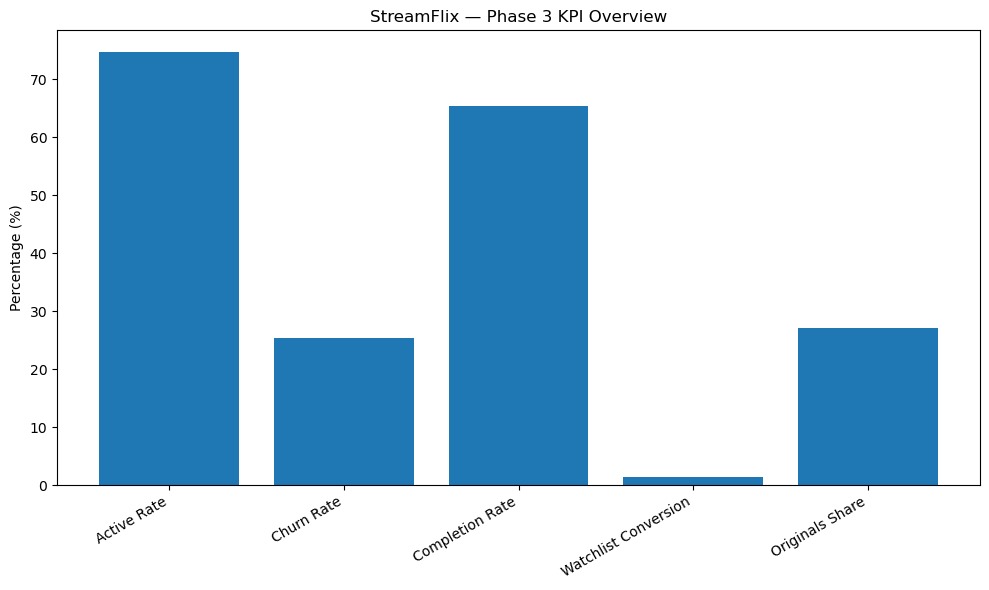

Chart saved: C:\Users\ASUS\Desktop\Internmo\Project - 3\phase3_results\Phase3_KPI_Overview.png


In [36]:
percentage_kpis = {
    "Active Rate": active_rate,
    "Churn Rate": churn_rate,
    "Completion Rate": avg_completion_rate,
    "Watchlist Conversion": watchlist_conversion,
    "Originals Share": originals_share
}

plt.figure(figsize=(10, 6))

plt.bar(
    percentage_kpis.keys(),
    percentage_kpis.values()
)

plt.ylabel("Percentage (%)")
plt.title("StreamFlix — Phase 3 KPI Overview")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

chart_path = os.path.join(
    RESULTS_PATH,
    "Phase3_KPI_Overview.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved:", chart_path)

### Final validation

In [37]:
print("========== PHASE 3 VALIDATION ==========")

print(f"Total Subscribers        : {total_subscribers:,}")
print(f"Active Subscribers       : {active_subscribers:,}")
print(f"Inactive Subscribers     : {inactive_subscribers:,}")

print(f"\nActive Rate              : {active_rate:.2f}%")
print(f"Churn Rate               : {churn_rate:.2f}%")
print(f"Rate Check               : {active_rate + churn_rate:.2f}%")

print(f"\nTotal Watch Hours        : {total_watch_hours:,.2f}")
print(f"Avg Completion Rate      : {avg_completion_rate:.2f}%")
print(f"MRR                      : ₹{mrr:,.2f}")
print(f"ARPU                     : ₹{arpu:,.2f}")
print(
    f"Avg Watch Time/User      : "
    f"{avg_watch_time_per_subscriber:.2f} hours"
)
print(f"Watchlist Conversion     : {watchlist_conversion:.2f}%")
print(f"Hit Concentration        : {hit_concentration:.2f}%")
print(f"Originals Share          : {originals_share:.2f}%")

print("\n========================================")
print("PHASE 3 KPI CALCULATION COMPLETED")
print("========================================")

========== PHASE 3 VALIDATION ==========
Total Subscribers        : 15,000
Active Subscribers       : 11,199
Inactive Subscribers     : 3,801

Active Rate              : 74.66%
Churn Rate               : 25.34%
Rate Check               : 100.00%

Total Watch Hours        : 3,333,467.73
Avg Completion Rate      : 65.31%
MRR                      : ₹0.00
ARPU                     : ₹0.00
Avg Watch Time/User      : 297.66 hours
Watchlist Conversion     : 1.43%
Hit Concentration        : 30.99%
Originals Share          : 27.17%

PHASE 3 KPI CALCULATION COMPLETED
